# Production Pipeline

> This notebook shows the complete of the workflow of the OCR pipeline.

An input snapshot of the score card is registered to a defined template of the same card, to extract cells of the score table with hand written digits.
These cell images are passed through a custom trained CNN for classification.

In the final output grid of images and their associated prediction, those with a confidence score of less than 0.90 are highlighted in red, and those between 0.90 and 0.95 are highlighted in blue.

In [1]:
import numpy as np
import cv2
import os, sys
from PIL import Image
import matplotlib.pyplot as plt
from skimage import io, filters, color
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))
MODELS_DIR = PROJECT_ROOT / "models"
sys.path.insert(0, str(MODELS_DIR))

temp_path = "..\\data\\Templates"
data_path = "..\\data\\Data2"
rawdata_path = "..\\data\\Data2\\Raw"
newdata_path = "..\\data\\Data2\\New"
regdata_path = "..\\data\\Data2\\Registered"

In [3]:
def load_img(img_f, img_dir=temp_path, points=None, show=False):
    """
    points: list of lists or array of lists. Inner list must have len 2.
    """
    img_p = os.path.join(img_dir, f"{img_f}.jpeg")
    i = io.imread(img_p)
    if i is None: raise ValueError("Image not found or unable to load.")
    if show:
        plt.figure(figsize=(8, 6))
        plt.imshow(i)

        if points is not None:
            pts = np.array(points)
            plt.scatter(pts[:, 0], pts[:, 1], c='red', s=10)

        plt.axis('off')
        plt.show()
    return i

# v2: Piecewise Homography (split-card) to address crease problem
def register_img(temp_img, samp_images, crease_x):
    orb = cv2.ORB_create(5000)
    # Use FLANN-based matching (faster/better for large feature sets)
    index_params = dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1)
    search_params = dict(checks=50)
    matcher = cv2.FlannBasedMatcher(index_params, search_params)

    # extract keypoints and descriptors from the template
    temp_kp, temp_des = orb.detectAndCompute(temp_img, None)
    height, width = temp_img.shape[:2]

    # results to be returned
    matched_images = []
    registered_images = []
    if not isinstance(samp_images, list): samp_images = [samp_images]
    for i, samp_img in enumerate(samp_images): 
        # extract keypoints and descriptors from the sample
        samp_kp, samp_des = orb.detectAndCompute(samp_img, None)
        # match descriptors of the template and sample
        matches = matcher.knnMatch(temp_des, samp_des, k=2)
        good_matches = [m for m, n in matches if m.distance < 0.7 * n.distance]
        
        if len(good_matches) > 20:
            match_img = cv2.drawMatches(temp_img, temp_kp, samp_img, samp_kp, good_matches, None, flags=2)
            points_temp = np.float32([temp_kp[m.queryIdx].pt for m in good_matches])
            points_samp = np.float32([samp_kp[m.trainIdx].pt for m in good_matches])

            # Split into Left and Right Panes
            left_mask = points_temp[:, 0] < crease_x
            right_mask = points_temp[:, 0] >= crease_x
            reg_img = np.zeros_like(temp_img)

            # Apply TWO Homographies (One for each side of the crease)
            for mask, x_range in [(left_mask, (0, crease_x)), (right_mask, (crease_x, width))]:
                if np.sum(mask) < 4: continue
                
                # Rigidly align just this half
                H, _ = cv2.findHomography(points_samp[mask], points_temp[mask], cv2.RANSAC, 5.0)
                warped = cv2.warpPerspective(samp_img, H, (width, height))
                
                # Stitch into final image
                x1, x2 = x_range
                reg_img[:, x1:x2] = warped[:, x1:x2]

            registered_images.append(reg_img)
            matched_images.append(match_img)
        else:
            print(f"Not enough matches found for sample {i}.")

    if len(registered_images) == 1: return registered_images[0], matched_images[0]
    return registered_images, matched_images


In [4]:
# TODO: move to separate utils file
def get_grid_from_points(points):
    pts = np.array(points)

    xs = np.round(pts[:, 0]).astype(int)
    ys = np.round(pts[:, 1]).astype(int)

    x_coords = np.unique(xs)
    y_coords = np.unique(ys)

    return np.sort(x_coords), np.sort(y_coords)

def crop_cells_grid(img, x_coords, y_coords, target_h=28, pad=0):
    grid = []

    for i in range(len(y_coords) - 1):
        row = []
        for j in range(len(x_coords) - 1):
            x1, x2 = x_coords[j] - pad, x_coords[j+1] + pad
            y1, y2 = y_coords[i] - pad, y_coords[i+1] + pad

            cell = img[y1:y2, x1:x2]
            # resize to target height
            h, w = cell.shape[:2]
            scale = target_h / h
            new_w = max(1, int(w * scale))

            cell_resized = cv2.resize(cell, (new_w, target_h), interpolation=cv2.INTER_AREA)
            row.append(cell_resized)
        grid.append(row)

    return grid

def show_cropped_grid(header_grid, score_grid, show_header=True, header_preds=None, score_preds=None):
    # 1. Prepare data
    full_display_grid = []
    if show_header:
        for h_row, s_row in zip(header_grid, score_grid):
            full_display_grid.append([h_row[0]] + s_row)
    else:
        full_display_grid = score_grid
        header_preds = None

    # 2. Determine grid dimensions
    num_rows = len(full_display_grid)
    num_cols = len(full_display_grid[0]) if num_rows > 0 else 0

    # 3. Create the subplot figure
    _, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 1))

    # 4. Fill the subplots
    for r in range(num_rows):
        for c in range(num_cols):
            ax = axes[r, c] if num_rows > 1 else axes[c]
            cell_img = full_display_grid[r][c]
            ax.imshow(cell_img, cmap='gray')

            if c == 0 and show_header:            # header cells titles
                if header_preds:
                    p, c = header_preds[r][0]
                    ax.set_title(f"{p} ({c:.2f})", fontsize=14)
            else:
                if score_preds:   # score cells titles
                    
                    pred_col = c - 1 if show_header else c
                    pred, conf = score_preds[r][pred_col]
                    if conf <= 0.95:
                        for spine in ax.spines.values():
                            if c < 0.9: spine.set_edgecolor('red')
                            else: spine.set_edgecolor('blue')
                            spine.set_linewidth(2)
                    ax.set_title(f"{pred} ({conf:.2f})", fontsize=14)
            # Clean up the look
            ax.set_xticks([])
            ax.set_yticks([])
            
    plt.subplots_adjust(wspace=0.02, hspace=0.5)
    plt.show()

In [5]:
# setup template (TODO: move to separate setup script)
x_pt = [106,254,730,782,1256]
y_pt = [668,716,766,816,866]
crease_x = 782
cells = np.linspace(254, 730, 10).tolist()[1:-1] + np.linspace(782, 1256, 10).tolist()[1:-1]
x_cells = x_pt[1:] + cells
x_cells = sorted(x_pt[1:] + cells)
header_cells = [[round(x),round(y)] for x in x_pt[:2] for y in y_pt]
score_cells = [
    [round(x),round(y)] for x in x_cells for y in y_pt
]
template_points = header_cells + score_cells
pts_template = np.array(template_points)
temp_i = load_img('Data2', points=pts_template, show=False)
height, width = temp_i.shape[0], temp_i.shape[1]
print(f"Template shape: {(width, height)}")
template = {
    'header_cells': header_cells,
    'score_cells': score_cells,
    'template_shape': (height, width),
    'crease_x': crease_x,
    'temp_i':temp_i
}

sx_coords, sy_coords = get_grid_from_points(template['score_cells'])  # score cells
hx_coords, hy_coords = get_grid_from_points(template['header_cells'])  # header cells

Template shape: (1600, 1199)


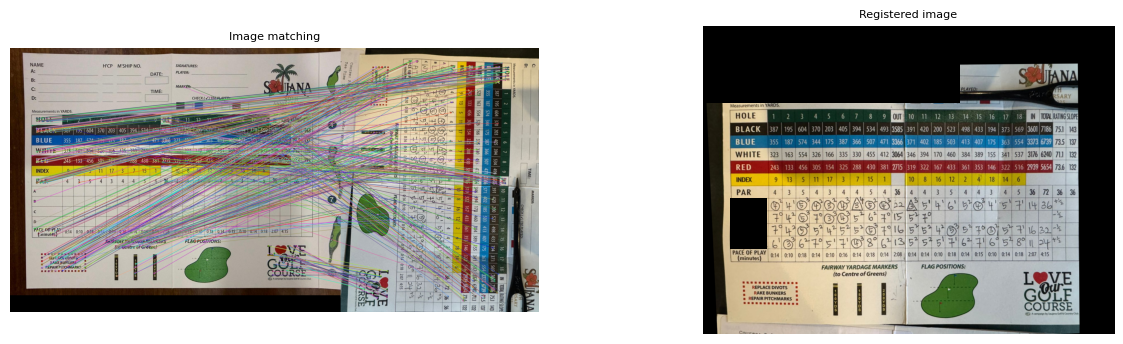

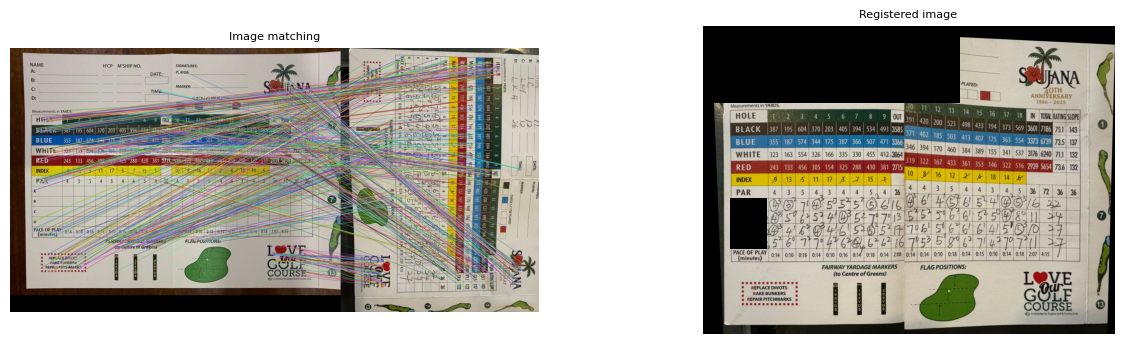

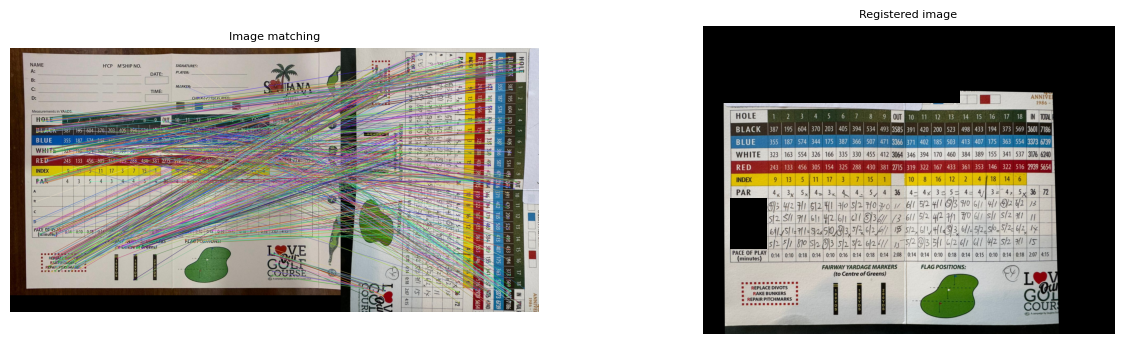

In [6]:
rect2_init = template['header_cells'][0]
rect2_width = template['header_cells'][-1][0] - template['header_cells'][0][0] - 6
rect2_height = template['header_cells'][-1][1] - template['header_cells'][0][1]
for i in range(1,4):
    test_image = f"image_{i}"
    test_i = load_img(test_image, img_dir=newdata_path)
    registered_i, matched_i = register_img(template['temp_i'], test_i, crease_x=template['crease_x'])
    mask_rect1 = plt.Rectangle((0, 0), 1000, 300, edgecolor=None, facecolor='black', linewidth=0)
    mask_rect2 = plt.Rectangle(rect2_init, rect2_width, rect2_height, edgecolor=None, facecolor='black', linewidth=0)
    fig, ax = plt.subplots(1, 2, figsize=(15,4))
    ax = ax.flatten()
    ax[0].imshow(matched_i)
    ax[0].set_title('Image matching', fontsize=8)
    ax[1].imshow(registered_i)
    ax[1].add_patch(mask_rect1)
    ax[1].add_patch(mask_rect2)
    ax[1].set_title('Registered image', fontsize=8)
    for a in ax: a.axis('off')

In [7]:
from cnn import CNN
import torchvision.transforms as T
import torch

infer_transform = T.Compose([
    T.Resize((48, 48)),
    T.Grayscale(num_output_channels=1),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])

weights_path = "..\\weights"
cnn_version = "cnn_v2.1"
model = CNN(num_classes=10)
state_dict = torch.load(os.path.join(weights_path, cnn_version, "cnn_real_train.pth"), map_location=model.device, weights_only=True)
model.load_state_dict(state_dict['model_state'])

<All keys matched successfully>

In [8]:
# TODO: add threshold for low-confidence predictions
def recognize_scorecard(grid, model, transform):
    model.eval()

    rows, cols = len(grid), len(grid[0])  # fixed in your case

    # Flatten grid
    flat_cells = [cell for row in grid for cell in row]

    # Apply transform
    tensors = [transform(Image.fromarray(cell)) for cell in flat_cells]

    # Stack into ONE batch
    batch = torch.stack(tensors).to(model.device)  # (72, C, H, W)

    with torch.no_grad():
        probs, logits = model(batch)
        preds = torch.argmax(logits, dim=1)
        confs = torch.max(probs, dim=1).values
        confs = confs.cpu().numpy()
        preds = preds.cpu().numpy()

    # Reshape back to grid
    preds_grid = preds.reshape(rows, cols)
    confs_grid = confs.reshape(rows, cols)
    result_grid = [[(preds_grid[i][j], confs_grid[i][j])
                    for j in range(cols)]
                    for i in range(rows)]
    
    return result_grid

def infer_scorecard(img, sx_coords, sy_coords, model, transform):
    test_i = load_img(img, img_dir=newdata_path)
    # test_i = preprocess(test_i)
    registered_i, _ = register_img(template['temp_i'], test_i, crease_x=template['crease_x'])
    score_grid = crop_cells_grid(registered_i, sx_coords, sy_coords, target_h=48, pad=4)
    score_grid = [row[:9] + row[10:] for row in score_grid]  # remove half sum column at i=9
    header_grid = crop_cells_grid(registered_i, hx_coords, hy_coords, target_h=48, pad=4)
    out = recognize_scorecard(score_grid, model, transform)
    return show_cropped_grid(header_grid, score_grid, False, None, out)

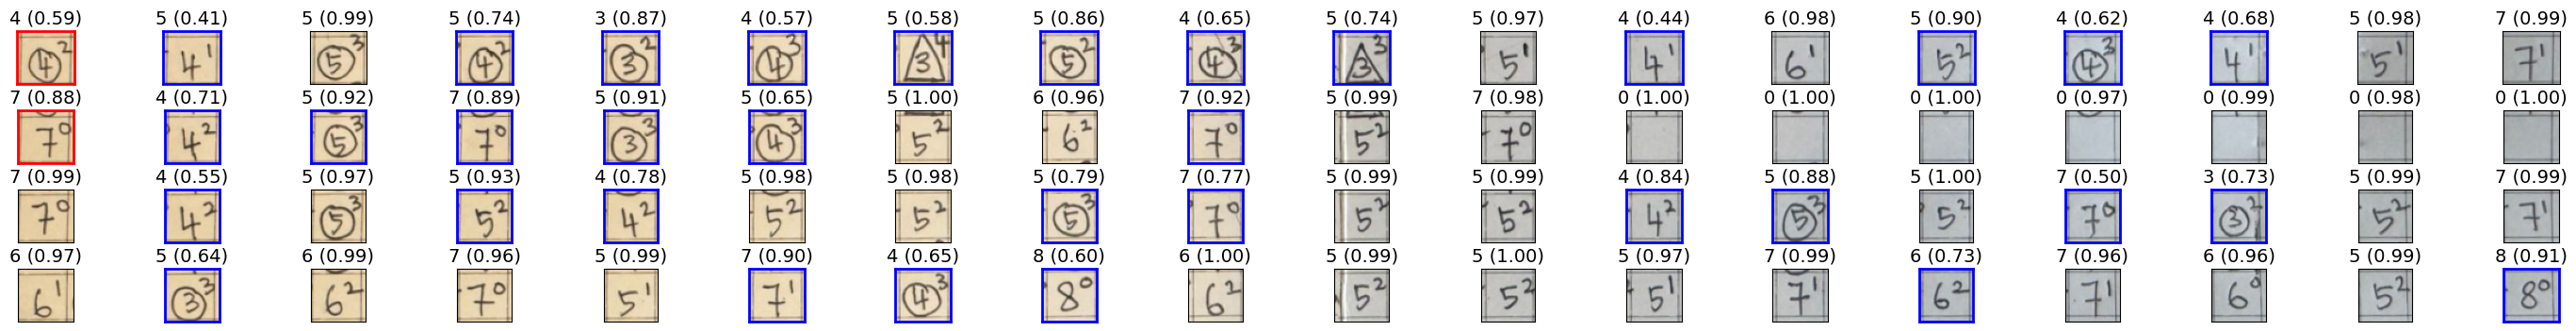

In [9]:
test_image = "image_1"
infer_scorecard(test_image, sx_coords, sy_coords, model, infer_transform)

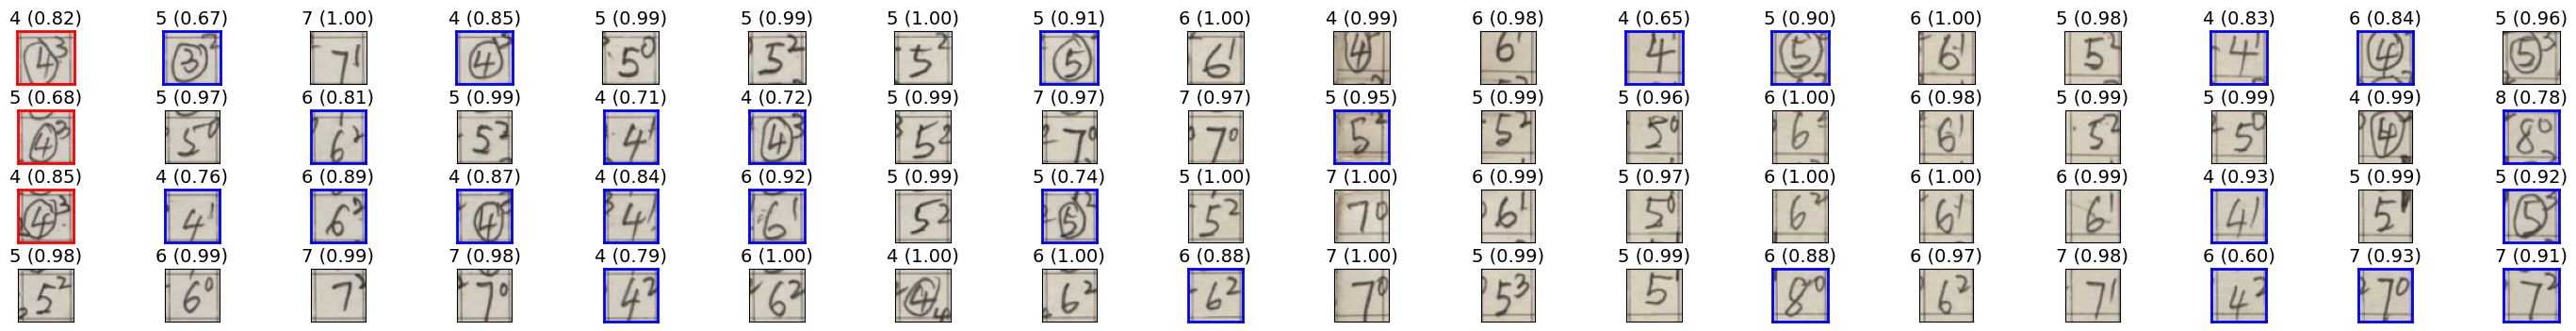

In [10]:
test_image = "image_2"
infer_scorecard(test_image, sx_coords, sy_coords, model, infer_transform)

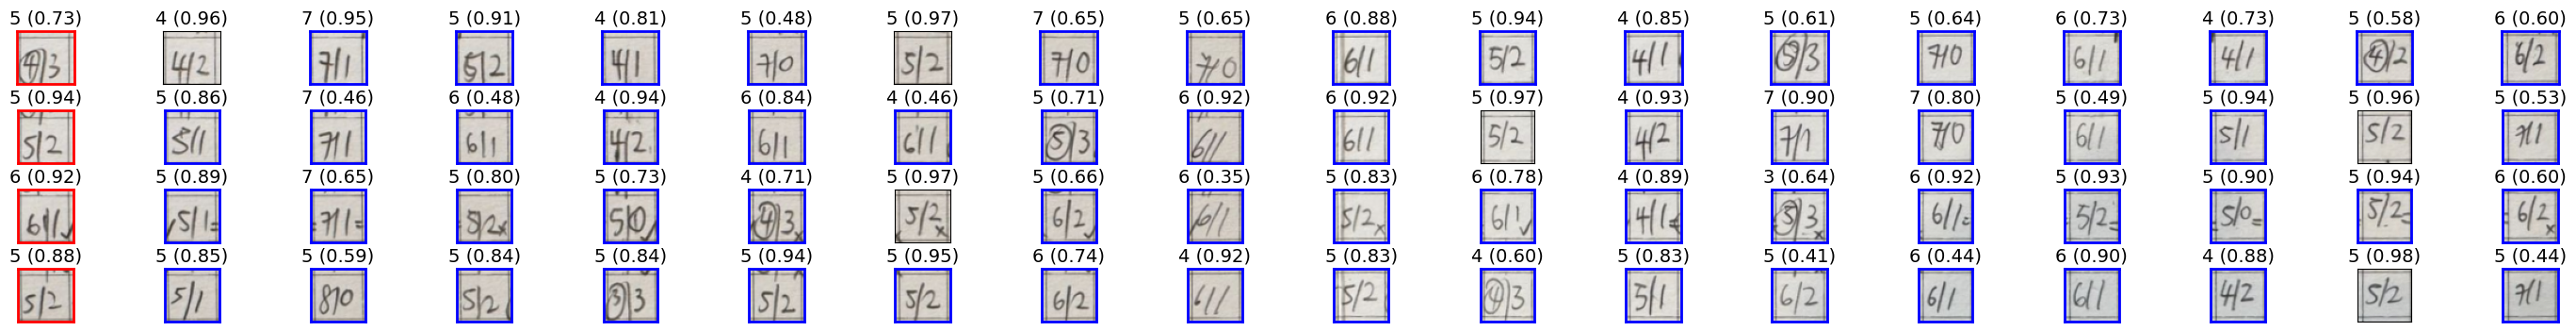

In [11]:
test_image = "image_3"
infer_scorecard(test_image, sx_coords, sy_coords, model, infer_transform)